<a href="https://colab.research.google.com/github/Parthwadekar40/ParthCM40-Pattern-Recognition/blob/main/prac_3_PR_Parth40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

👉 Please upload your email dataset CSV file below:


Saving SMSSpamCollection to SMSSpamCollection (1)

✅ File successfully loaded: SMSSpamCollection (1)
Dataset Dimensions: 5571 rows, 2 columns

--- Initial Data Sample ---
                                          email_text  label
0                      Ok lar... Joking wif u oni...      0
1  Free entry in 2 a wkly comp to win FA Cup fina...      1
2  U dun say so early hor... U c already then say...      0
3  Nah I don't think he goes to usf, he lives aro...      0
4  FreeMsg Hey there darling it's been 3 week's n...      1

⏳ Preprocessing text corpus...
✅ Text preprocessing completed.

⏳ Initializing and training Naïve Bayes Classifier...
✅ Model training complete.

                 PRACTICAL PERFORMANCE REPORT          
Overall Model Accuracy: 0.9722
ROC AUC Score:          0.9840

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Ham (0)       0.97      1.00      0.98       965
    Spam (1)       1.00      0.79      0.88       150



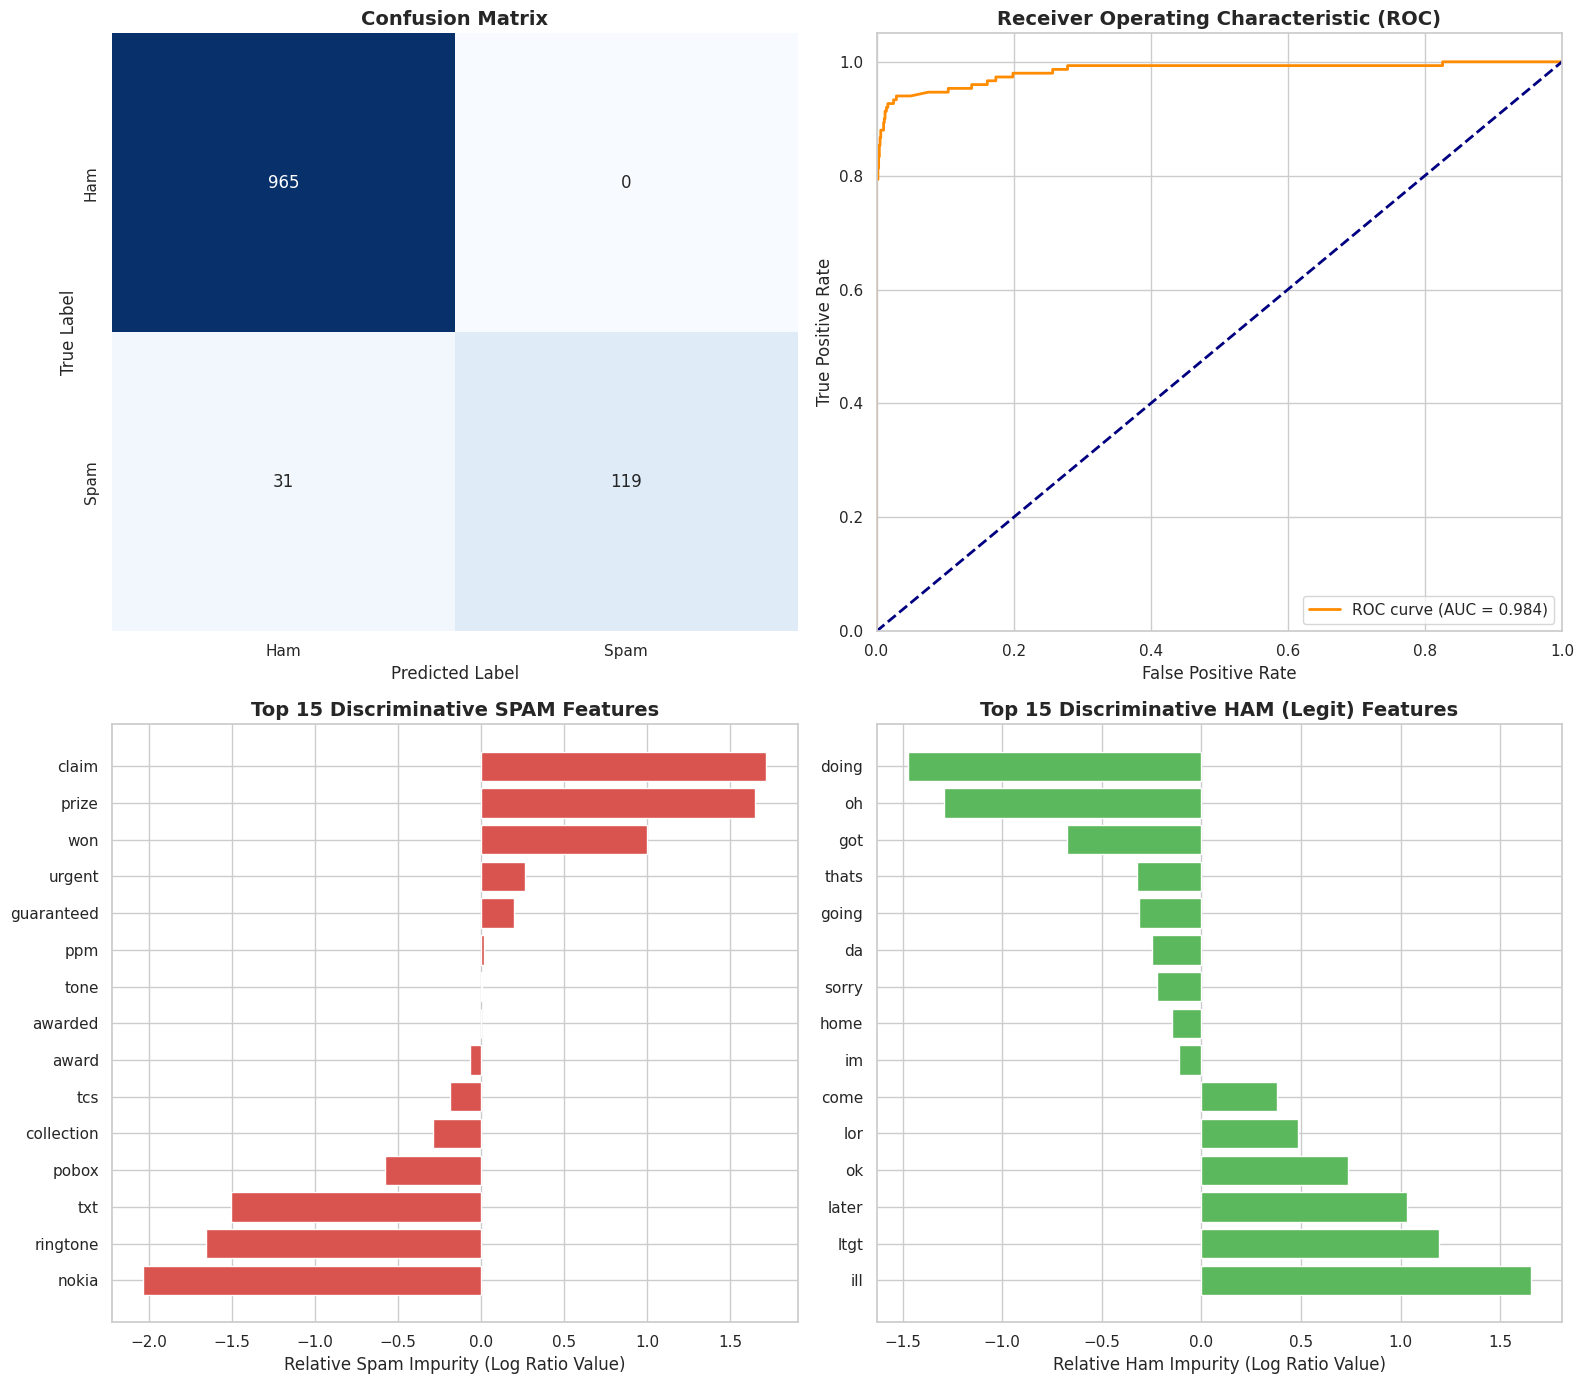

In [2]:
# =====================================================================
# STEP 1: IMPORT LIBRARIES & UPLOAD DATASET
# =====================================================================
import io
import re
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import files
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print("👉 Please upload your email dataset CSV file below:")
uploaded = files.upload()

# Read the uploaded CSV file securely
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]), encoding="latin-1", sep='\t')

print(f"\n✅ File successfully loaded: {file_name}")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

# =====================================================================
# STEP 2: DATA CLEANING & COLUMN EXTRACTION
# =====================================================================
# Auto-detect column configurations based on common datasets (like SMS Spam Collection)
text_col = None
label_col = None

possible_text_cols = ["text", "message", "sms", "v2", "email"]
possible_label_cols = ["label", "target", "v1", "category"]

for col in df.columns:
    if col.lower() in possible_text_cols:
        text_col = col
    if col.lower() in possible_label_cols:
        label_col = col

# Fallback defaults if exact match isn't found
if not text_col or not label_col:
    text_col = df.columns[1] if len(df.columns) > 1 else df.columns[0]
    label_col = df.columns[0]

# Clean structure and drop unused columns
df = df[[text_col, label_col]].copy()
df.columns = ["email_text", "label"]
df = df.dropna()

# Map labels uniformly to Binary Outcomes (1 = Spam, 0 = Ham)
if df["label"].dtype == "object":
    df["label"] = (
        df["label"]
        .str.lower()
        .map({"spam": 1, "ham": 0, "legit": 0, "1": 1, "0": 0})
    )

print("\n--- Initial Data Sample ---")
print(df.head())


# =====================================================================
# STEP 3: TEXT PREPROCESSING FUNCTION
# =====================================================================
def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()
    # Remove HTML Tags
    text = re.sub(r"<.*?>", "", text)
    # Remove special characters, digits, and punctuation
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Clean redundant whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text


print("\n⏳ Preprocessing text corpus...")
df["cleaned_text"] = df["email_text"].apply(preprocess_text)
print("✅ Text preprocessing completed.")

# =====================================================================
# STEP 4: TRAIN-TEST SPLIT & FEATURE EXTRACTION (TF-IDF)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned_text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

# Using TF-IDF vectorizer while filtering out standard English stop words
vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# =====================================================================
# STEP 5: MODEL TRAINING (MULTINOMIAL NAÏVE BAYES)
# =====================================================================
print("\n⏳ Initializing and training Naïve Bayes Classifier...")
nb_classifier = MultinomialNB(alpha=1.0)  # Laplace smoothing enabled
nb_classifier.fit(X_train_vectorized, y_train)
print("✅ Model training complete.")

# Predict probabilities and hard classes
y_pred = nb_classifier.predict(X_test_vectorized)
y_prob = nb_classifier.predict_proba(X_test_vectorized)[:, 1]

# =====================================================================
# STEP 6: DISCRIMINATIVE FEATURE ANALYSIS (CRITICAL FOR YOUR PRACTICAL)
# =====================================================================
# Extract empirical log probabilities assigned to words by the classifier
feature_names = np.array(vectorizer.get_feature_names_out())
spam_log_prob = nb_classifier.feature_log_prob_[1]
ham_log_prob = nb_classifier.feature_log_prob_[0]

# Calculate log-likelihood ratio to find the most pure indicators of spam vs ham
log_ratio = spam_log_prob - ham_log_prob

top_spam_idx = np.argsort(log_ratio)[-15:]
top_ham_idx = np.argsort(log_ratio)[:15]

top_spam_words = feature_names[top_spam_idx]
top_ham_words = feature_names[top_ham_idx]

# =====================================================================
# STEP 7: PRINT EVALUATION METRICS
# =====================================================================
print("\n" + "=" * 50)
print("                 PRACTICAL PERFORMANCE REPORT          ")
print("=" * 50)
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score:          {roc_auc_score(y_test, y_prob):.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Ham (0)", "Spam (1)"]))

# =====================================================================
# STEP 8: RENDER COMPREHENSIVE VISUALIZATIONS
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"],
)
axes[0, 0].set_title("Confusion Matrix", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Predicted Label", fontsize=12)
axes[0, 0].set_ylabel("True Label", fontsize=12)

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0, 1].plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC curve (AUC = {roc_auc_score(y_test, y_prob):.3f})",
)
axes[0, 1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel("False Positive Rate", fontsize=12)
axes[0, 1].set_ylabel("True Positive Rate", fontsize=12)
axes[0, 1].set_title("Receiver Operating Characteristic (ROC)", fontsize=14, fontweight="bold")
axes[0, 1].legend(loc="lower right")

# Plot 3: Top Discriminative Spam Features
axes[1, 0].barh(top_spam_words, sorted(log_ratio[-15:]), color="#d9534f")
axes[1, 0].set_title("Top 15 Discriminative SPAM Features", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Relative Spam Impurity (Log Ratio Value)", fontsize=12)

# Plot 4: Top Discriminative Ham Features
axes[1, 1].barh(top_ham_words, sorted(log_ratio[:15], reverse=True), color="#5cb85c")
axes[1, 1].set_title("Top 15 Discriminative HAM (Legit) Features", fontsize=14, fontweight="bold")
axes[1, 1].set_xlabel("Relative Ham Impurity (Log Ratio Value)", fontsize=12)

plt.tight_layout()
plt.show()